In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/mountain_dataset.csv', converters={'marker': eval})

## Dataset description

In [2]:
df.head()

,text,marker
0,A visit to a science museum for hands-on learn...,[]
1,Voice surface coach set democratic time year. ...,[]
2,Parent according maybe activity activity finis...,[]
3,A visit to a sculpture garden with intriguing ...,[]
4,The Julian Alps in Slovenia offer pristine lak...,"[(11, 15)]"


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1584 entries, 0 to 1583
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    1584 non-null   str   
 1   marker  1584 non-null   object
dtypes: object(1), str(1)
memory usage: 24.9+ KB


## Dataset Exploration

In [4]:
def split_markers(text, markers):
    splitted_markers = []
    
    for start, end in markers:
        
        # Extract the mountain name
        mountain_name = text[start:end]

        # Split the mountain name into individual words
        words = mountain_name.split(" ")

        # Generate separate marker for each word
        for word in words:
            word_start = text.find(word, start)
            word_end = word_start + len(word)
            splitted_markers.append((word_start, word_end))

    
    return splitted_markers


df['markers'] = df.apply(lambda row: split_markers(row['text'], row['marker']), axis=1)

In [5]:
df.head()

,text,marker,markers
0,A visit to a science museum for hands-on learn...,[],[]
1,Voice surface coach set democratic time year. ...,[],[]
2,Parent according maybe activity activity finis...,[],[]
3,A visit to a sculpture garden with intriguing ...,[],[]
4,The Julian Alps in Slovenia offer pristine lak...,"[(11, 15)]","[(11, 15)]"


In [6]:
df['mountain_count'] = df['markers'].apply(len)
df['mountain_count'].value_counts(normalize=True)

mountain_count
0    0.857323
2    0.080177
1    0.046086
3    0.015783
5    0.000631
Name: proportion, dtype: float64

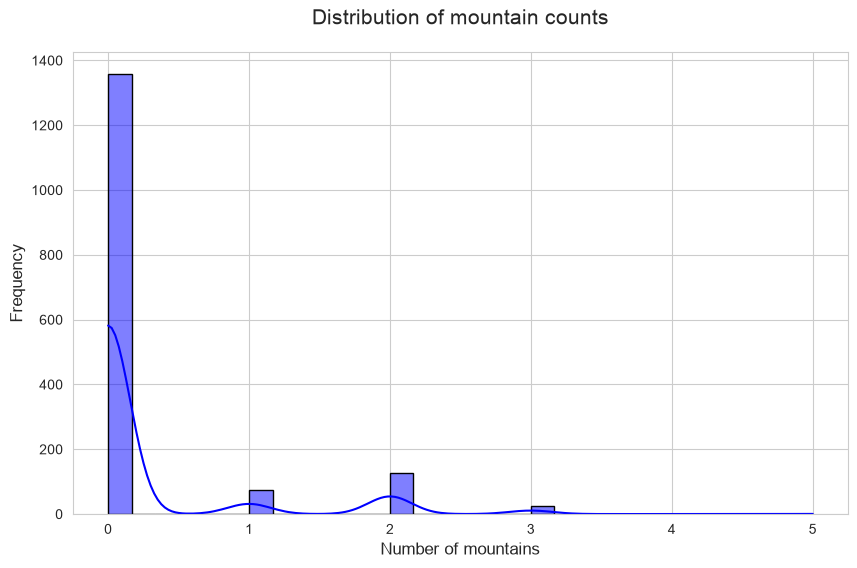

In [7]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

sns.histplot(df['mountain_count'], bins=30, kde=True, color='blue', edgecolor='black')

plt.title("Distribution of mountain counts", fontsize=15, pad=20)
plt.xlabel("Number of mountains", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.show()

In [8]:
def get_mountains(row):
    text, loc_markers = row['text'], row['markers']
    return [text[i:j] for i, j in loc_markers]

In [13]:
mountain_record = df[df['mountain_count'] >= 1].iloc[100]
print(mountain_record.text)

mountains = get_mountains(mountain_record)
print(f"Observed moutnains: {mountains}")

The Southern Alps in New Zealand offer stunning landscapes.
Observed moutnains: ['Alps']


In [10]:
mountains = df.apply(get_mountains, axis=1)

mountain_sub_titles = []

for mountain_title in mountains.to_list():
    for sub_title in mountain_title:
        mountain_sub_titles.append(sub_title)

pd.Series(mountain_sub_titles).value_counts()

Mountains       82
Mount           45
Alps            34
Andes           23
Himalayas       19
Range           12
Taurus          12
Everest          9
Rhodope          9
Appalachian      8
Rocky            8
Shan             7
Fuji             7
Kilimanjaro      7
Scandinavian     7
Kunlun           5
Denali           5
Rainier          5
Sierra           5
Olympus          5
Carpathian       4
Tatra            4
Blue             4
Ridge            4
Cascade          4
Tien             4
Brooks           4
Great            4
Dividing         4
Atlas            4
Patagonian       4
Drakensberg      4
Dolomites        3
Tian             3
Rwenzori         3
Nevada           3
mountains        3
Elbrus           3
Apennine         3
Cook             3
Ural             3
St.              2
Helens           2
Madre            2
Occidental       2
Kenya            2
Columbia         2
Icefield         2
Dolomite         1
Eiger            1
K2               1
Logan            1
Name: count,